In [291]:
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path

In [292]:
DATA_PATH = r'C:\@Python Projects\TUT Research Project\Data\HZL_RA4_Pb_Rougher_2023-06.parquet'

df = pd.read_parquet(DATA_PATH)
df.sort_index(inplace=True)
print("Raw shape:", df.shape)

df.info(memory_usage='deep')

Raw shape: (21569, 115)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21569 entries, 2023-06-01 00:01:06.240996096 to 2023-06-30 23:58:13.590597888
Columns: 115 entries, MillFeedRate to month
dtypes: float64(113), int32(2)
memory usage: 18.9 MB


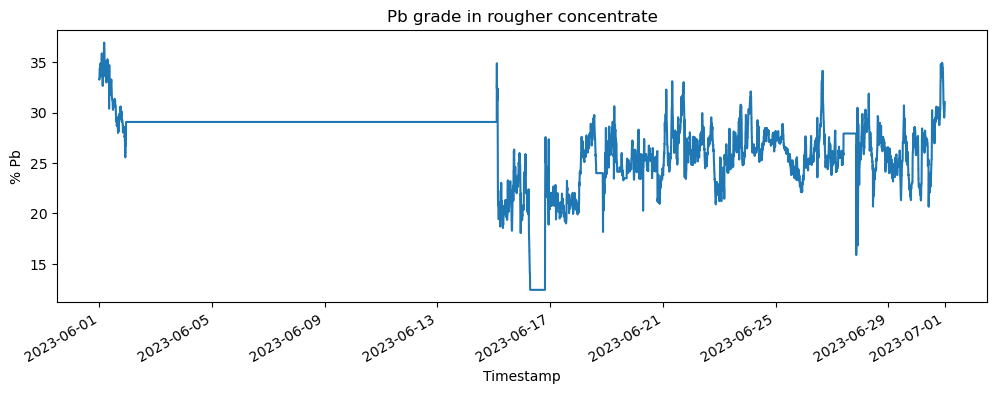

In [293]:
# %% Cell 16 ─ Quick sanity plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
df['Pb_Rougher_Conc_Pb'].plot(ax=ax, title='Pb grade in rougher concentrate')
ax.set_ylabel('% Pb')
plt.show()

Remove Duplicates

In [294]:
# %% Cell 4 ─ Ensure index is datetime & unique
df.index = pd.to_datetime(df.index, errors='coerce')
df = df.sort_index()
df = df[~df.index.duplicated(keep='first')]

:::Authority == 1 for every controlled unit
:::InvalidData == 0 for every unit that exposes it

In [295]:
#Operational validity mask (Boolean, keep invalid rows as NaNs)
units = ['Pb_Rougher1', 'Pb_Rougher2', 'Pb_Scavenger1'] + \
        [f'Pb_Cleaner{i}' for i in (1, 2, 3)]

mask = pd.Series(True, index=df.index)
for u in units:
    if f'{u}_FSLSStatus' in df:
        mask &= df[f'{u}_FSLSStatus'] == 1
    if f'{u}_Authority' in df:
        mask &= df[f'{u}_Authority'] == 1
    if f'{u}_InvalidData' in df:
        mask &= df[f'{u}_InvalidData'] == 0

df_clean = df.copy()
df_clean.loc[~mask] = np.nan   # invalidate rows, keep index

Report & drop near-all-NaN / near-zero-variance columns

In [ ]:
missing = df_clean.isna().mean()
near_all_nan = missing[missing >= 0.95]
if not near_all_nan.empty:
    print("Columns ≥95 % NaN:\n", near_all_nan)

variance = df_clean.var()
near_zero_var = variance[variance < 1e-12]
if not near_zero_var.empty:
    print("Near-zero-variance columns:\n", near_zero_var)

drop_cols = near_all_nan.index.union(near_zero_var.index)
df_clean = df_clean.drop(columns=drop_cols)

Get min/max for each numeric column (excluding 'Invalid_Flat' if present)

In [297]:

# --- Get grade columns from Extract.ipynb mapping ---
grade_columns = [
    'Feed_Pb', 'Feed_Zn', 'Pb_Rougher_Conc_Pb', 'Pb_Rougher_Conc_Zn',
    'Pb_Final_Conc_Pb', 'Pb_Final_Conc_Zn', 'Pb_Scavenger_Tails_Pb', 'Pb_Scavenger_Tails_Zn'
]

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.drop('Invalid_Flat', errors='ignore')
col_ranges = {}
for col in numeric_cols:
    col_lower = col.lower()
    # Grades: fixed range 0-100
    if col in grade_columns:
        col_ranges[col] = (0, 100)
    # Valves/Flowrates: use _Min/_Max columns if present
    elif (('valve' in col_lower or 'rate' in col_lower) and not col_lower.endswith('_min') and not col_lower.endswith('_max')):
        min_col = f"{col}_Min"
        max_col = f"{col}_Max"
        if min_col in df_clean.columns and max_col in df_clean.columns:
            col_ranges[col] = (df_clean[min_col].min(), df_clean[max_col].max())
        else:
            # fallback to data min/max if no _Min/_Max columns
            col_ranges[col] = (df_clean[col].min(), df_clean[col].max())
    else:
        # fallback to data min/max for all others
        col_ranges[col] = (df_clean[col].min(), df_clean[col].max())

Group columns by identical (min, max) ranges

In [298]:
range_to_cols = defaultdict(list)
for col, rng in col_ranges.items():
    range_to_cols[rng].append(col)


# Drop columns with ≥ 95 % missing or zero-variance

In [299]:
# For each group of columns with the same (min, max) range, flag out-of-range values
for rng, cols in range_to_cols.items():
    min_val, max_val = rng
    for col in cols:
        # Mark as NaN if out of range
        mask_col = (df_clean[col] >= min_val) & (df_clean[col] <= max_val)
        df_clean.loc[~mask_col, col] = np.nan

# Very short forward-fill (1 sample = 5 min max)

In [300]:

cont_vars = [c for c in df_clean.columns if c.startswith(('Pb_', 'Feed_'))]
df_clean[cont_vars] = df_clean[cont_vars].ffill(limit=1)

Clip extreme outliers

In [ ]:
for c in cont_vars:
    lo, hi = df_clean[c].quantile([.01, .99])
    df_clean[c] = df_clean[c].clip(lower=lo, upper=hi)

Regular 5-min grid with resampleRe-index to equidistant 5-minute grid

In [ ]:
df_clean = df_clean.resample('5T').mean()

Create derived targets & features


In [ ]:
# 12a. Feed ratio
df_clean['Feed_Pb_ratio'] = (
    df_clean['Feed_Pb'] /
    (df_clean['Feed_Pb'] + df_clean['Feed_Zn'])
)

# 12b. Rolling 15-min means
for col in ['Pb_Rougher1_AirFlow', 'Pb_Rougher2_AirFlow']:
    if col in df_clean:
        df_clean[f'{col}_roll15'] = df_clean[col].rolling('15T').mean()

# 12c. Lagged variables (5, 15, 30, 60 min)
lag_cols = [
    'Feed_Pb', 'Feed_Zn', 'Feed_Pb_ratio',
    'Pb_Rougher1_SIPX_Flowrate',
    'Pb_Rougher2_KEX_Flowrate',
    'Pb_Conditioner_KEX_Flowrate',
    'Pb_Conditioner_Nigrosine_Flowrate'
]
for c in lag_cols:
    if c in df_clean:
        for lag in [1, 3, 6, 12]:   # 5, 15, 30, 60 min
            df_clean[f'{c}_lag{lag*5}min'] = df_clean[c].shift(lag)

Drop any row that still contains NaNs (guarantees contiguous windows)

In [304]:

df_final = df_clean.dropna()
print("Final shape:", df_final.shape)

Final shape: (0, 146)


Save cleaned dataset

In [305]:
Clean_DataPath = r'C:\@Python Projects\TUT Research Project\Cleaned Data\HZL_RA4_Pb_Rougher_2023-07_clean.parquet'
df_final.to_parquet(Clean_DataPath)

IndexError: index 0 is out of bounds for axis 0 with size 0

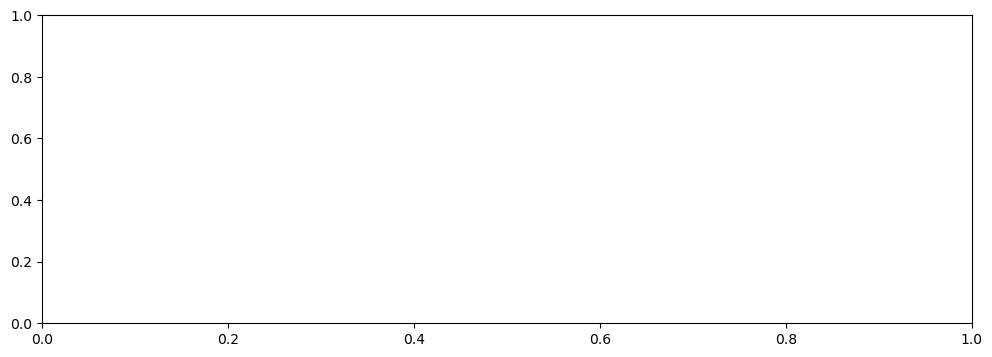

In [306]:
# %% Cell 16 ─ Quick sanity plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
df_final['Pb_Rougher_Conc_Pb'].plot(ax=ax, title='Pb grade in rougher concentrate')
ax.set_ylabel('% Pb')
plt.show()